In [1]:
# ============================================
# AI Resume Analyzer & Job Recommendation System
# IBM SkillsBuild AI Internship Project
# ============================================

print("🚀 AI Resume Analyzer Project Started!")

# Import basic libraries
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt

print("✅ Basic libraries loaded successfully!")

🚀 AI Resume Analyzer Project Started!
✅ Basic libraries loaded successfully!


In [3]:
# Install NLP libraries
!pip -q install nltk scikit-learn

import nltk

nltk.download('punkt')
nltk.download('stopwords')

print("✅ NLP libraries ready!")

✅ NLP libraries ready!


[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [4]:
# ============================================
# TASK 4: Create Job Dataset
# ============================================

jobs = [
    {
        "Job_Role": "Data Analyst",
        "Skills": "python, sql, excel, pandas, statistics, data visualization, power bi"
    },
    {
        "Job_Role": "Business Analyst",
        "Skills": "excel, sql, business analysis, data analysis, communication, power bi, statistics"
    },
    {
        "Job_Role": "Financial Analyst",
        "Skills": "excel, financial analysis, accounting, statistics, financial modeling, powerpoint"
    },
    {
        "Job_Role": "Marketing Analyst",
        "Skills": "marketing, excel, data analysis, statistics, communication, google analytics"
    },
    {
        "Job_Role": "Project Coordinator",
        "Skills": "project management, communication, excel, teamwork, leadership, powerpoint"
    },
    {
        "Job_Role": "HR Analyst",
        "Skills": "excel, communication, data analysis, human resources, statistics, powerpoint"
    },
    {
        "Job_Role": "AI/ML Intern",
        "Skills": "python, machine learning, artificial intelligence, pandas, numpy, scikit-learn"
    },
    {
        "Job_Role": "Data Scientist",
        "Skills": "python, machine learning, statistics, pandas, numpy, sql, data visualization"
    },
    {
        "Job_Role": "Operations Analyst",
        "Skills": "excel, data analysis, operations management, sql, communication, problem solving"
    },
    {
        "Job_Role": "Finance & Business Analyst",
        "Skills": "excel, finance, accounting, business analysis, sql, data analysis, power bi"
    }
]

jobs_df = pd.DataFrame(jobs)

print("✅ Job dataset created successfully!")
print(f"📊 Total job roles: {len(jobs_df)}")

jobs_df

✅ Job dataset created successfully!
📊 Total job roles: 10


,Job_Role,Skills
0,Data Analyst,"python, sql, excel, pandas, statistics, data v..."
1,Business Analyst,"excel, sql, business analysis, data analysis, ..."
2,Financial Analyst,"excel, financial analysis, accounting, statist..."
3,Marketing Analyst,"marketing, excel, data analysis, statistics, c..."
4,Project Coordinator,"project management, communication, excel, team..."
5,HR Analyst,"excel, communication, data analysis, human res..."
6,AI/ML Intern,"python, machine learning, artificial intellige..."
7,Data Scientist,"python, machine learning, statistics, pandas, ..."
8,Operations Analyst,"excel, data analysis, operations management, s..."
9,Finance & Business Analyst,"excel, finance, accounting, business analysis,..."


In [6]:
# ============================================
# TASK 5: Resume Skill Extraction
# ============================================

# Master list of skills our AI system can detect
skill_database = [
    "python",
    "sql",
    "excel",
    "pandas",
    "numpy",
    "statistics",
    "data analysis",
    "data visualization",
    "power bi",
    "business analysis",
    "financial analysis",
    "accounting",
    "financial modeling",
    "marketing",
    "google analytics",
    "project management",
    "communication",
    "teamwork",
    "leadership",
    "powerpoint",
    "human resources",
    "machine learning",
    "artificial intelligence",
    "scikit-learn",
    "operations management",
    "problem solving",
    "finance"
]

# Sample resume for testing
sample_resume = """
MBA student with experience in Business Analytics and Data Analysis.
Skilled in Excel, SQL, Python, Power BI and Microsoft PowerPoint.
Completed projects using Pandas and NumPy.
Knowledge of statistics, data visualization and business analysis.
Strong communication, teamwork and problem solving skills.
Interested in Finance, Business Analytics and Artificial Intelligence.
"""

# Convert resume text to lowercase
resume_text = sample_resume.lower()

# Detect skills
detected_skills = []

for skill in skill_database:
    if skill in resume_text:
        detected_skills.append(skill)

print("🤖 AI Resume Analyzer")
print("=" * 40)
print("Detected Skills:")
print()

for skill in detected_skills:
    print("✅", skill)

print()
print("📊 Total skills detected:", len(detected_skills))

🤖 AI Resume Analyzer
Detected Skills:

✅ python
✅ sql
✅ excel
✅ pandas
✅ numpy
✅ statistics
✅ data analysis
✅ data visualization
✅ power bi
✅ business analysis
✅ communication
✅ teamwork
✅ powerpoint
✅ artificial intelligence
✅ problem solving
✅ finance

📊 Total skills detected: 16


In [7]:
# ============================================
# TASK 6: AI Job Matching Engine
# ============================================

def calculate_job_match(resume_skills, job_skills):
    """
    Compare resume skills with job requirements
    and calculate a job match score.
    """

    # Convert skills into sets
    resume_set = set(resume_skills)
    job_set = set(job_skills)

    # Find matching and missing skills
    matching_skills = resume_set.intersection(job_set)
    missing_skills = job_set - resume_set

    # Calculate percentage
    match_score = (len(matching_skills) / len(job_set)) * 100

    return matching_skills, missing_skills, match_score


# Calculate match for every job
results = []

for _, job in jobs_df.iterrows():

    # Convert job skill string into list
    job_skills = [
        skill.strip().lower()
        for skill in job["Skills"].split(",")
    ]

    matching, missing, score = calculate_job_match(
        detected_skills,
        job_skills
    )

    results.append({
        "Job Role": job["Job_Role"],
        "Match Score": round(score, 2),
        "Matching Skills": ", ".join(sorted(matching)),
        "Missing Skills": ", ".join(sorted(missing))
    })


# Create results dataframe
results_df = pd.DataFrame(results)

# Sort from highest to lowest match
results_df = results_df.sort_values(
    by="Match Score",
    ascending=False
).reset_index(drop=True)


print("🤖 AI JOB MATCHING RESULTS")
print("=" * 60)

results_df[[
    "Job Role",
    "Match Score"
]]

🤖 AI JOB MATCHING RESULTS


,Job Role,Match Score
0,Data Analyst,100.00
1,Business Analyst,100.00
2,Finance & Business Analyst,85.71
3,Data Scientist,85.71
4,HR Analyst,83.33
5,Operations Analyst,83.33
6,Marketing Analyst,66.67
7,Project Coordinator,66.67
8,AI/ML Intern,66.67
9,Financial Analyst,50.00


In [8]:
# ============================================
# TASK 7: Top Job Recommendations & Skill Gap
# ============================================

# Get the highest match score
top_score = results_df["Match Score"].max()

# Get all jobs having the highest score
top_jobs = results_df[
    results_df["Match Score"] == top_score
]

print("🏆 TOP JOB RECOMMENDATIONS")
print("=" * 60)

for _, row in top_jobs.iterrows():

    print(f"\n🎯 {row['Job Role']}")
    print(f"📊 Skill Match Score: {row['Match Score']}%")

    print("\n✅ Matching Skills:")
    print(row["Matching Skills"])

    print("\n⚠️ Skills to Improve:")

    if row["Missing Skills"]:
        print(row["Missing Skills"])
    else:
        print("No major missing skills detected.")

    print("-" * 60)


# Overall skill-gap analysis
all_missing_skills = set()

for _, row in results_df.iterrows():
    if row["Missing Skills"]:
        for skill in row["Missing Skills"].split(", "):
            all_missing_skills.add(skill)

print("\n💡 OVERALL SKILL DEVELOPMENT SUGGESTIONS")
print("=" * 60)

for skill in sorted(all_missing_skills):
    print("➡️", skill)

🏆 TOP JOB RECOMMENDATIONS

🎯 Data Analyst
📊 Skill Match Score: 100.0%

✅ Matching Skills:
data visualization, excel, pandas, power bi, python, sql, statistics

⚠️ Skills to Improve:
No major missing skills detected.
------------------------------------------------------------

🎯 Business Analyst
📊 Skill Match Score: 100.0%

✅ Matching Skills:
business analysis, communication, data analysis, excel, power bi, sql, statistics

⚠️ Skills to Improve:
No major missing skills detected.
------------------------------------------------------------

💡 OVERALL SKILL DEVELOPMENT SUGGESTIONS
➡️ accounting
➡️ financial analysis
➡️ financial modeling
➡️ google analytics
➡️ human resources
➡️ leadership
➡️ machine learning
➡️ marketing
➡️ operations management
➡️ project management
➡️ scikit-learn


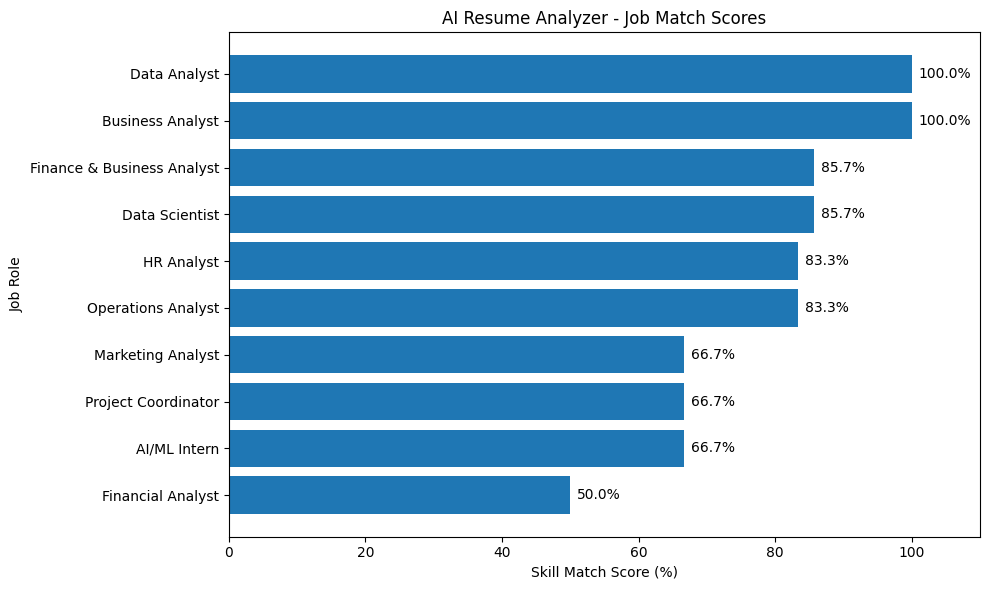

In [9]:
# ============================================
# TASK 8: Job Match Visualization
# ============================================

plt.figure(figsize=(10, 6))

plt.barh(
    results_df["Job Role"],
    results_df["Match Score"]
)

plt.xlabel("Skill Match Score (%)")
plt.ylabel("Job Role")
plt.title("AI Resume Analyzer - Job Match Scores")

# Display highest match at the top
plt.gca().invert_yaxis()

# Add score labels
for index, score in enumerate(results_df["Match Score"]):
    plt.text(
        score + 1,
        index,
        f"{score:.1f}%",
        va="center"
    )

plt.xlim(0, 110)
plt.tight_layout()
plt.show()

In [10]:
# ============================================
# TASK 9: NLP-Based Resume-Job Similarity
# TF-IDF + Cosine Similarity
# ============================================

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

# Create a TF-IDF vectorizer
vectorizer = TfidfVectorizer(
    stop_words="english"
)

# Combine resume with all job descriptions
documents = [sample_resume] + jobs_df["Skills"].tolist()

# Convert text into TF-IDF vectors
tfidf_matrix = vectorizer.fit_transform(documents)

# Compare resume with every job
resume_vector = tfidf_matrix[0]
job_vectors = tfidf_matrix[1:]

similarity_scores = cosine_similarity(
    resume_vector,
    job_vectors
)[0]

# Add NLP similarity score to our results
results_df["NLP Similarity"] = [
    round(score * 100, 2)
    for score in similarity_scores
]

# Sort according to NLP similarity
nlp_results = results_df.sort_values(
    by="NLP Similarity",
    ascending=False
).reset_index(drop=True)

print("🧠 NLP-BASED RESUME-JOB SIMILARITY")
print("=" * 60)

print(
    nlp_results[
        ["Job Role", "NLP Similarity"]
    ]
)

🧠 NLP-BASED RESUME-JOB SIMILARITY
                     Job Role  NLP Similarity
0            Business Analyst           47.43
1           Financial Analyst           44.01
2                Data Analyst           35.00
3              Data Scientist           28.49
4                AI/ML Intern           27.24
5         Project Coordinator           26.36
6           Marketing Analyst           20.92
7          Operations Analyst           20.02
8                  HR Analyst           14.34
9  Finance & Business Analyst            9.58


In [11]:
# ============================================
# TASK 10: Final AI Recommendation Score
# ============================================

# Combine skill matching and NLP similarity
results_df["Final AI Score"] = (
    0.70 * results_df["Match Score"] +
    0.30 * results_df["NLP Similarity"]
)

# Round the final score
results_df["Final AI Score"] = results_df["Final AI Score"].round(2)

# Sort by final AI score
final_results = results_df.sort_values(
    by="Final AI Score",
    ascending=False
).reset_index(drop=True)

print("🤖 FINAL AI JOB RECOMMENDATION")
print("=" * 70)

print(
    final_results[
        ["Job Role", "Match Score", "NLP Similarity", "Final AI Score"]
    ]
)

🤖 FINAL AI JOB RECOMMENDATION
                     Job Role  Match Score  NLP Similarity  Final AI Score
0            Business Analyst       100.00           47.43           84.23
1                Data Analyst       100.00           35.00           80.50
2              Data Scientist        85.71           28.49           68.54
3          Operations Analyst        83.33           20.02           64.34
4  Finance & Business Analyst        85.71            9.58           62.87
5                  HR Analyst        83.33           14.34           62.63
6                AI/ML Intern        66.67           27.24           54.84
7         Project Coordinator        66.67           26.36           54.58
8           Marketing Analyst        66.67           20.92           52.94
9           Financial Analyst        50.00           44.01           48.20


In [12]:
# ============================================
# TASK 11: AI Resume Analyzer Dashboard
# ============================================

# Get the top recommendation
best_job = final_results.iloc[0]

print("\n" + "=" * 70)
print("              🤖 AI RESUME ANALYZER")
print("=" * 70)

print(f"\n👤 Skills Detected: {len(detected_skills)}")

print("\n🏆 BEST JOB RECOMMENDATION")
print("-" * 70)
print(f"Job Role       : {best_job['Job Role']}")
print(f"Final AI Score : {best_job['Final AI Score']}%")
print(f"Skill Match    : {best_job['Match Score']}%")
print(f"NLP Similarity : {best_job['NLP Similarity']}%")

print("\n" + "=" * 70)
print("📊 TOP 5 RECOMMENDED JOBS")
print("=" * 70)

print(
    final_results[
        ["Job Role", "Final AI Score"]
    ].head(5).to_string(index=False)
)

print("\n" + "=" * 70)
print("💡 SKILLS DETECTED")
print("=" * 70)

for skill in detected_skills:
    print("✓", skill)

print("\n" + "=" * 70)
print("🚀 ANALYSIS COMPLETE")
print("=" * 70)


              🤖 AI RESUME ANALYZER

👤 Skills Detected: 16

🏆 BEST JOB RECOMMENDATION
----------------------------------------------------------------------
Job Role       : Business Analyst
Final AI Score : 84.23%
Skill Match    : 100.0%
NLP Similarity : 47.43%

📊 TOP 5 RECOMMENDED JOBS
                  Job Role  Final AI Score
          Business Analyst           84.23
              Data Analyst           80.50
            Data Scientist           68.54
        Operations Analyst           64.34
Finance & Business Analyst           62.87

💡 SKILLS DETECTED
✓ python
✓ sql
✓ excel
✓ pandas
✓ numpy
✓ statistics
✓ data analysis
✓ data visualization
✓ power bi
✓ business analysis
✓ communication
✓ teamwork
✓ powerpoint
✓ artificial intelligence
✓ problem solving
✓ finance

🚀 ANALYSIS COMPLETE


In [13]:
# ============================================
# TASK 12: Resume Upload
# ============================================

from google.colab import files

print("📄 Upload your resume (.txt file)")
uploaded = files.upload()

# Read uploaded resume
for filename in uploaded.keys():
    with open(filename, "r", encoding="utf-8") as file:
        uploaded_resume = file.read()

print("\n✅ Resume uploaded successfully!")
print("📄 File:", filename)
print("📝 Characters:", len(uploaded_resume))

print("\nResume Preview:")
print(uploaded_resume[:500])

📄 Upload your resume (.txt file)


Saving AARAV SHARMA dummy resume.docx to AARAV SHARMA dummy resume.docx


UnicodeDecodeError: 'utf-8' codec can't decode byte 0xc9 in position 15: invalid continuation byte

In [20]:
# ============================================
# TASK 12 FIX: Resume Upload
# Supports TXT and DOCX
# ============================================

from google.colab import files

print("📄 Upload your resume (.txt or .docx)")
uploaded = files.upload()

filename = list(uploaded.keys())[0]

# Read TXT resume
if filename.lower().endswith(".txt"):

    with open(filename, "r", encoding="utf-8") as file:
        uploaded_resume = file.read()

# Read DOCX resume
elif filename.lower().endswith(".docx"):

    !pip -q install python-docx

    from docx import Document

    document = Document(filename)

    paragraphs = []

    for paragraph in document.paragraphs:
        if paragraph.text.strip():
            paragraphs.append(paragraph.text.strip())

    uploaded_resume = "\n".join(paragraphs)

else:
    print("❌ Unsupported file type.")
    uploaded_resume = ""

# Display result
if uploaded_resume:

    print("\n✅ Resume uploaded successfully!")
    print("📄 File:", filename)
    print("📝 Characters:", len(uploaded_resume))

    print("\n📋 Resume Preview:")
    print("-" * 60)
    print(uploaded_resume[:1000])
    print("-" * 60)

📄 Upload your resume (.txt or .docx)


Saving Test_Resume_2.txt to Test_Resume_2.txt

✅ Resume uploaded successfully!
📄 File: Test_Resume_2.txt
📝 Characters: 376

📋 Resume Preview:
------------------------------------------------------------
RIYA MEHTA

EDUCATION
MBA in Finance

SKILLS
Excel
Financial Analysis
Accounting
Financial Modeling
PowerPoint
Communication
Statistics
Business Analysis

EXPERIENCE
Finance Intern with experience in financial reporting,
budget analysis and business analysis.

PROJECTS
Created financial analysis reports using Excel.
Performed statistical analysis and prepared presentations.
------------------------------------------------------------


In [21]:
# ============================================
# RESUME UPLOAD + AI SKILL DETECTION
# ============================================

!pip -q install python-docx pypdf

from google.colab import files
from docx import Document
import os
import re

print("📄 Upload your resume (.docx, .pdf or .txt)")
uploaded = files.upload()

filename = list(uploaded.keys())[0]

print("\n✅ Resume uploaded successfully!")
print("📄 File:", filename)


# --------------------------------------------
# EXTRACT RESUME TEXT
# --------------------------------------------

def extract_text(filename):

    # TXT file
    if filename.lower().endswith(".txt"):
        with open(filename, "r", encoding="utf-8", errors="ignore") as f:
            return f.read()

    # DOCX file
    elif filename.lower().endswith(".docx"):
        doc = Document(filename)
        text = []

        for paragraph in doc.paragraphs:
            text.append(paragraph.text)

        return "\n".join(text)

    # PDF file
    elif filename.lower().endswith(".pdf"):
        from pypdf import PdfReader

        reader = PdfReader(filename)
        text = []

        for page in reader.pages:
            text.append(page.extract_text() or "")

        return "\n".join(text)

    else:
        return ""


resume_text = extract_text(filename)

print("\n✅ Resume text extracted successfully!")
print("\nResume Preview:")
print(resume_text[:1000])


# --------------------------------------------
# SKILL DATABASE
# --------------------------------------------

skill_database = [
    "python",
    "sql",
    "excel",
    "pandas",
    "numpy",
    "statistics",
    "data analysis",
    "data visualization",
    "power bi",
    "tableau",
    "business analysis",
    "communication",
    "teamwork",
    "powerpoint",
    "artificial intelligence",
    "machine learning",
    "problem solving",
    "finance",
    "accounting",
    "financial analysis",
    "financial modeling",
    "marketing",
    "human resources",
    "leadership",
    "operations management",
    "project management",
    "scikit-learn"
]


# --------------------------------------------
# DETECT SKILLS
# --------------------------------------------

resume_lower = resume_text.lower()

uploaded_detected_skills = []

for skill in skill_database:
    if skill.lower() in resume_lower:
        uploaded_detected_skills.append(skill)


# --------------------------------------------
# FINAL OUTPUT
# --------------------------------------------

print("\n\n🤖 UPLOADED RESUME ANALYSIS")
print("=" * 60)

print("\n📄 Resume File:")
print(filename)

print("\n🎯 Skills Detected:")

if len(uploaded_detected_skills) > 0:
    for skill in uploaded_detected_skills:
        print("✓", skill)
else:
    print("No skills detected.")

print(
    f"\n📊 Total Skills Detected: "
    f"{len(uploaded_detected_skills)}"
)

print("\n✅ Resume analysis completed successfully!")

📄 Upload your resume (.docx, .pdf or .txt)


Saving Test_Resume_2.txt to Test_Resume_2 (1).txt

✅ Resume uploaded successfully!
📄 File: Test_Resume_2 (1).txt

✅ Resume text extracted successfully!

Resume Preview:
RIYA MEHTA

EDUCATION
MBA in Finance

SKILLS
Excel
Financial Analysis
Accounting
Financial Modeling
PowerPoint
Communication
Statistics
Business Analysis

EXPERIENCE
Finance Intern with experience in financial reporting,
budget analysis and business analysis.

PROJECTS
Created financial analysis reports using Excel.
Performed statistical analysis and prepared presentations.


🤖 UPLOADED RESUME ANALYSIS

📄 Resume File:
Test_Resume_2 (1).txt

🎯 Skills Detected:
✓ excel
✓ statistics
✓ business analysis
✓ communication
✓ powerpoint
✓ finance
✓ accounting
✓ financial analysis
✓ financial modeling

📊 Total Skills Detected: 9

✅ Resume analysis completed successfully!


In [22]:
# ============================================
# FINAL ANALYSIS OF UPLOADED RESUME
# ============================================

print("🤖 FINAL UPLOADED RESUME ANALYSIS")
print("=" * 70)

# Resume information
print("\n📄 Resume File:")
print(filename)

# Skills detected
print("\n🎯 SKILLS DETECTED")
print("-" * 50)

for skill in uploaded_detected_skills:
    print("✓", skill)

print(f"\n📊 Total Skills Detected: {len(uploaded_detected_skills)}")


# ============================================
# JOB ROLE SKILL MATCHING
# ============================================

resume_skills = set(skill.lower() for skill in uploaded_detected_skills)

results = []

for _, row in jobs_df.iterrows():

    job_role = row["Job_Role"]

    job_skills = [
        skill.strip().lower()
        for skill in str(row["Skills"]).split(",")
    ]

    matched = resume_skills.intersection(job_skills)

    match_score = (
        len(matched) / len(job_skills) * 100
        if len(job_skills) > 0 else 0
    )

    results.append({
        "Job Role": job_role,
        "Skill Match Score": round(match_score, 2),
        "Matching Skills": ", ".join(sorted(matched)) if matched else "None"
    })


# Convert to DataFrame
uploaded_results = pd.DataFrame(results)

# Sort highest match first
uploaded_results = uploaded_results.sort_values(
    by="Skill Match Score",
    ascending=False
).reset_index(drop=True)


# ============================================
# DISPLAY RESULTS
# ============================================

print("\n\n🎯 JOB ROLE RECOMMENDATIONS")
print("=" * 70)

print(
    uploaded_results[
        ["Job Role", "Skill Match Score", "Matching Skills"]
    ].to_string(index=False)
)


# ============================================
# BEST JOB RECOMMENDATION
# ============================================

best_job = uploaded_results.iloc[0]

print("\n\n🏆 BEST JOB RECOMMENDATION")
print("=" * 70)

print("Job Role        :", best_job["Job Role"])
print("Skill Match     :", str(best_job["Skill Match Score"]) + "%")
print("Matching Skills :", best_job["Matching Skills"])


# ============================================
# TOP 5 JOBS
# ============================================

print("\n\n⭐ TOP 5 RECOMMENDED JOBS")
print("=" * 70)

print(
    uploaded_results[
        ["Job Role", "Skill Match Score"]
    ].head(5).to_string(index=False)
)

print("\n✅ Uploaded Resume Analysis Completed Successfully!")

🤖 FINAL UPLOADED RESUME ANALYSIS

📄 Resume File:
Test_Resume_2 (1).txt

🎯 SKILLS DETECTED
--------------------------------------------------
✓ excel
✓ statistics
✓ business analysis
✓ communication
✓ powerpoint
✓ finance
✓ accounting
✓ financial analysis
✓ financial modeling

📊 Total Skills Detected: 9


🎯 JOB ROLE RECOMMENDATIONS
                  Job Role  Skill Match Score                                                                   Matching Skills
         Financial Analyst             100.00 accounting, excel, financial analysis, financial modeling, powerpoint, statistics
                HR Analyst              66.67                                      communication, excel, powerpoint, statistics
Finance & Business Analyst              57.14                                     accounting, business analysis, excel, finance
          Business Analyst              57.14                               business analysis, communication, excel, statistics
       Project Coordinator 

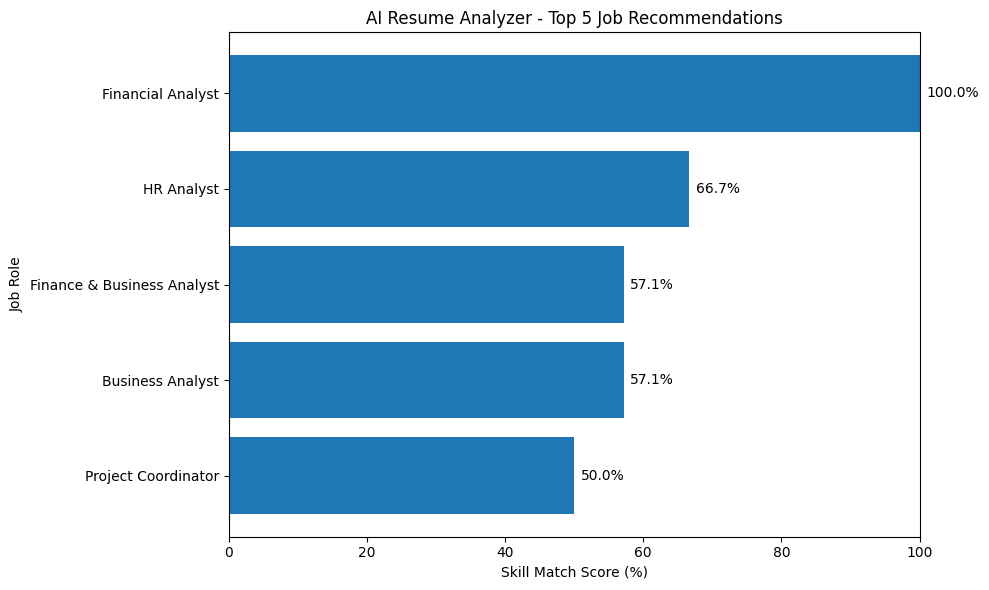

In [23]:
# ============================================
# TOP JOB RECOMMENDATIONS - VISUALIZATION
# ============================================

import matplotlib.pyplot as plt

top_jobs = uploaded_results.head(5).copy()

plt.figure(figsize=(10, 6))

plt.barh(
    top_jobs["Job Role"][::-1],
    top_jobs["Skill Match Score"][::-1]
)

plt.xlabel("Skill Match Score (%)")
plt.ylabel("Job Role")
plt.title("AI Resume Analyzer - Top 5 Job Recommendations")

plt.xlim(0, 100)

for i, score in enumerate(top_jobs["Skill Match Score"][::-1]):
    plt.text(score + 1, i, f"{score:.1f}%", va="center")

plt.tight_layout()
plt.show()

In [24]:
# ============================================
# FINAL AI RESUME ANALYZER DASHBOARD
# ============================================

best_job = uploaded_results.iloc[0]

print("\n" + "=" * 75)
print("              🤖 AI RESUME ANALYZER")
print("         IBM SkillsBuild AI Internship")
print("=" * 75)

print("\n📄 RESUME")
print("-" * 75)
print("File:", filename)

print("\n🎯 SKILL ANALYSIS")
print("-" * 75)
print("Total Skills Detected:", len(uploaded_detected_skills))

print("\n🏆 BEST JOB RECOMMENDATION")
print("-" * 75)
print("Recommended Role:", best_job["Job Role"])
print("Skill Match Score:", str(best_job["Skill Match Score"]) + "%")

print("\n⭐ TOP 5 JOB RECOMMENDATIONS")
print("-" * 75)

top5 = uploaded_results.head(5)

for i, (_, row) in enumerate(top5.iterrows(), start=1):
    print(
        f"{i}. {row['Job Role']} "
        f"→ {row['Skill Match Score']}%"
    )

print("\n💡 DETECTED SKILLS")
print("-" * 75)

print(", ".join(uploaded_detected_skills))

print("\n" + "=" * 75)
print("              ✅ ANALYSIS COMPLETE")
print("=" * 75)


              🤖 AI RESUME ANALYZER
         IBM SkillsBuild AI Internship

📄 RESUME
---------------------------------------------------------------------------
File: Test_Resume_2 (1).txt

🎯 SKILL ANALYSIS
---------------------------------------------------------------------------
Total Skills Detected: 9

🏆 BEST JOB RECOMMENDATION
---------------------------------------------------------------------------
Recommended Role: Financial Analyst
Skill Match Score: 100.0%

⭐ TOP 5 JOB RECOMMENDATIONS
---------------------------------------------------------------------------
1. Financial Analyst → 100.0%
2. HR Analyst → 66.67%
3. Finance & Business Analyst → 57.14%
4. Business Analyst → 57.14%
5. Project Coordinator → 50.0%

💡 DETECTED SKILLS
---------------------------------------------------------------------------
excel, statistics, business analysis, communication, powerpoint, finance, accounting, financial analysis, financial modeling

              ✅ ANALYSIS COMPLETE
